#West of Hudson river - VRP for Citi Bikes
Optimisation of vehicle routing to replace citi bikes in Jersey City and Hoboken

In [1]:
import pandas as pd
import numpy as np
import os
import folium

##EDA

Downloading weather data

In [2]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

import openmeteo_requests
import requests_cache
from retry_requests import retry

# Setup Open-Meteo client
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# API endpoint
url = "https://archive-api.open-meteo.com/v1/archive"

# Your coordinates + dates
params = {
    "latitude": 40.726090505954055,
    "longitude": -74.0531882697198,
    "start_date": "2025-04-01",
    "end_date": "2026-03-31",
    "hourly": "rain"
}

# Request data
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

# Extract hourly rain
hourly = response.Hourly()
rain = hourly.Variables(0).ValuesAsNumpy()

# Build dataframe
df_weather = pd.DataFrame({
    "datetime": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "rain_mm": rain
})

# Convert to daily totals
df_weather["date"] = df_weather["datetime"].dt.date

daily_rain = (
    df_weather.groupby("date")["rain_mm"]
    .sum()
    .reset_index()
)

print(daily_rain)

           date  rain_mm
0    2025-04-01     25.0
1    2025-04-02      0.0
2    2025-04-03      1.5
3    2025-04-04      7.2
4    2025-04-05      1.4
..          ...      ...
360  2026-03-27      4.3
361  2026-03-28      0.0
362  2026-03-29      0.0
363  2026-03-30      0.0
364  2026-03-31      0.6

[365 rows x 2 columns]


Downloading the trips data

In [3]:
# loading from the GitHub repository

!git clone {'https://github.com/HaydelOne/SLO-data-1y'}

Cloning into 'SLO-data-1y'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 37 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 36.56 MiB | 2.98 MiB/s, done.
Resolving deltas: 100% (22/22), done.


Concatenate all months into one metadata file

In [4]:
import os
os.chdir('/content/SLO-data-1y') # Ensure we are in the correct directory for SLO-data-1y

# Get the list of all CSV files in the current directory
# Only include files that contain 'citibike-tripdata' in their name
csv_files = [f for f in os.listdir('.') if f.endswith('.csv') and 'citibike-tripdata' in f]

# Initialize an empty list to hold dataframes
all_dfs = []

# Loop through each CSV file, read it, and append to the list
print(f"Loading {len(csv_files)} CSV files...")
for file in csv_files:
    print(f"Loading {file}...")
    df_temp = pd.read_csv(file)
    all_dfs.append(df_temp)

# Concatenate all dataframes into df_1y
if all_dfs:
    df_1y = pd.concat(all_dfs, ignore_index=True)
    print(f"Successfully loaded and concatenated {len(all_dfs)} files.")
    print(f"Total number of lines in the aggregated dataset: {len(df_1y)}")
    display(df_1y.head())
else:
    print("No CSV files found to aggregate.")
    df_1y = pd.DataFrame() # Initialize an empty DataFrame if no files are found

Loading 12 CSV files...
Loading JC-202505-citibike-tripdata.csv...
Loading JC-202601-citibike-tripdata.csv...
Loading JC-202512-citibike-tripdata.csv...
Loading JC-202504-citibike-tripdata.csv...
Loading JC-202506-citibike-tripdata.csv...
Loading JC-202603-citibike-tripdata.csv...
Loading JC-202511-citibike-tripdata.csv...
Loading JC-202507-citibike-tripdata.csv...
Loading JC-202509-citibike-tripdata.csv...
Loading JC-202508-citibike-tripdata.csv...
Loading JC-202602-citibike-tripdata.csv...
Loading JC-202510-citibike-tripdata.csv...
Successfully loaded and concatenated 12 files.
Total number of lines in the aggregated dataset: 961765


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,E4F548BF3BDC9E08,electric_bike,2025-05-20 15:35:37.858,2025-05-20 15:40:42.825,Hoboken Terminal - Hudson St & Hudson Pl,HB101,Newport PATH,JC066,40.735938,-74.030305,40.727224,-74.033759,member
1,760AC0F17953E290,classic_bike,2025-05-08 09:18:21.618,2025-05-08 09:25:44.348,Hoboken Terminal - Hudson St & Hudson Pl,HB101,Newport PATH,JC066,40.735938,-74.030305,40.727224,-74.033759,member
2,958826E821B25316,electric_bike,2025-05-16 14:31:31.147,2025-05-16 14:34:53.259,Hoboken Terminal - Hudson St & Hudson Pl,HB101,Church Sq Park - 5 St & Park Ave,HB601,40.735938,-74.030305,40.742659,-74.032233,member
3,2FFC6FF06AC742E1,electric_bike,2025-05-05 14:31:37.555,2025-05-05 14:35:28.478,Hoboken Terminal - Hudson St & Hudson Pl,HB101,Church Sq Park - 5 St & Park Ave,HB601,40.735938,-74.030305,40.742659,-74.032233,member
4,D2F0D983175EF26E,electric_bike,2025-05-18 11:56:32.631,2025-05-18 12:23:16.346,Hoboken Terminal - Hudson St & Hudson Pl,HB101,Morris Canal,JC072,40.735938,-74.030305,40.712419,-74.038526,member


Remove missing values and classical bikes

In [5]:
initial_rows = len(df_1y)
df_1y = df_1y.dropna()
suppressed_lines = initial_rows - len(df_1y)

print(f"Number of lines suppressed due to missing values: {suppressed_lines}")


Number of lines suppressed due to missing values: 5649


In [6]:
# Calculate the percentage of electric bikes and regular bikes (initial)
bike_type_counts = df_1y['rideable_type'].value_counts()
total_bikes = bike_type_counts.sum()

percentage_bike_types = (bike_type_counts / total_bikes) * 100
print("Initial Percentage of Each Bike Type:")
display(percentage_bike_types.to_frame(name='Percentage'))

# Delete rows with 'classic_bike'
initial_bike_rows = len(df_1y)
df_1y = df_1y[df_1y['rideable_type'] != 'classic_bike']
deleted_classic_bike_rows = initial_bike_rows - len(df_1y)
print(f"Number of 'classic_bike' rows deleted: {deleted_classic_bike_rows}")


Initial Percentage of Each Bike Type:


,Percentage
rideable_type,
electric_bike,64.158324
classic_bike,35.841676


Number of 'classic_bike' rows deleted: 342688


Jersey City and Hoboken stations

In [7]:
unique_start_stations = df_1y['start_station_id'].unique()
unique_end_stations = df_1y['end_station_id'].unique()

all_unique_stations = pd.Series(pd.concat([pd.Series(unique_start_stations), pd.Series(unique_end_stations)])).unique()

# Ensure all_unique_stations is treated as a string array for string operations
all_unique_stations_str = np.array(all_unique_stations).astype(str)

# Count stations starting with 'HB'
hb_stations = [station_id for station_id in all_unique_stations_str if station_id.startswith('HB')]
num_hb_stations = len(hb_stations)

# Count stations starting with 'JC'
jc_stations = [station_id for station_id in all_unique_stations_str if station_id.startswith('JC')]
num_jc_stations = len(jc_stations)

print(f"Number of unique station IDs in Jersey City and Hoboken : {num_hb_stations + num_jc_stations}")

Number of unique station IDs in Jersey City and Hoboken : 110


In [8]:

# Consolidate all unique station information from df_1y
# Check if df_1y is empty before proceeding, as it might have been reset by previous deletions
if not df_1y.empty:
    start_stations_info = df_1y[['start_station_id', 'start_lat', 'start_lng']].drop_duplicates()
    start_stations_info.columns = ['station_id', 'latitude', 'longitude']

    end_stations_info = df_1y[['end_station_id', 'end_lat', 'end_lng']].drop_duplicates()
    end_stations_info.columns = ['station_id', 'latitude', 'longitude']

    # Combine and remove duplicates based on 'station_id'
    all_stations_geo = pd.concat([start_stations_info, end_stations_info]).drop_duplicates(subset=['station_id'])

    # Drop any rows where latitude or longitude might still be missing
    all_stations_geo = all_stations_geo.dropna(subset=['latitude', 'longitude'])

    if all_stations_geo.empty:
        print("After consolidating, no valid station coordinates were found to plot.")
    else:
        # Get the center of the map using the mean of all station coordinates
        map_center_lat = all_stations_geo['latitude'].mean()
        map_center_lng = all_stations_geo['longitude'].mean()

        # Create a Folium map
        m = folium.Map(location=[map_center_lat, map_center_lng], zoom_start=12)

        # Add markers for each station
        for idx, row in all_stations_geo.iterrows():
            station_id = str(row['station_id'])
            if station_id.startswith('HB') or station_id.startswith('JC'):
                folium.Marker(
                    location=[row['latitude'], row['longitude']],
                    popup=station_id,
                    icon=folium.Icon(color='pink')
                ).add_to(m)
            else:
                folium.Marker(
                    location=[row['latitude'], row['longitude']],
                    popup=station_id
                ).add_to(m)

        # Display the map
        display(m)
else:
    print("The DataFrame 'df_1y' is empty. Please ensure data is loaded and processed before attempting to plot stations.")
    print("You might need to re-run the cells that load and clean the data (e.g., cell `a535f099` and `fo5cjiglrIx1`).")

In [9]:
jc_hb_stations = all_stations_geo[
    all_stations_geo['station_id'].astype(str).str.startswith(('JC', 'HB'))
]
center_lat = jc_hb_stations['latitude'].mean()
center_lng = jc_hb_stations['longitude'].mean()

print(f"Center point of all JC and HB stations:")
print(f"Latitude: {center_lat}")
print(f"Longitude: {center_lng}")

Center point of all JC and HB stations:
Latitude: 40.726090505954076
Longitude: -74.05318826971978


Cheching the assumption that 00:00-04:00 is insignificant.

In [10]:
df_1y['started_at'] = pd.to_datetime(df_1y['started_at'])
# Extract the hour from the 'started_at' column
df_1y['start_hour'] = df_1y['started_at'].dt.hour
# Removed df_1y['start_minute'] as it's no longer needed for a 04:00 end time

# Filter for rides between 00:00 and 04:00 (exclusive of 04:00)
rides_between_00_04 = df_1y[(df_1y['start_hour'] >= 0) & (df_1y['start_hour'] <= 4)]

# Calculate the percentage
total_rides = len(df_1y)
rides_in_timeframe_count = len(rides_between_00_04)

if total_rides > 0:
    percentage = (rides_in_timeframe_count / total_rides) * 100
    print(f"Percentage of rides between 00:00 and 04:00: {percentage:.2f}%")
else:
    print("No rides found in the DataFrame to calculate the percentage.")

Percentage of rides between 00:00 and 04:00: 3.11%



New dataframe “demand” that will contain the demand *for each station for each day*.

To do so :

We swap the batteries a certain percentage of the arrivals. To ensure the target is met, we wound up to the superior whole number if there is a decimal demand.

The 2 different columns (replacement demand and additional demand) contain :
- If the difference is negative -> the absolute value of the difference (in additional demand).
- If the difference is positive -> the number of total arrival that day multiplied by the replacement rate (in replacement demand).


In [11]:
replacement_rate = 0.2723

In [12]:
df_1y['started_at_date'] = pd.to_datetime(df_1y['started_at']).dt.date
df_1y['ended_at_date'] = pd.to_datetime(df_1y['ended_at']).dt.date

# Calculate daily departures per station
departures = df_1y.groupby(['started_at_date', 'start_station_id']).size().reset_index(name='departures')
departures.rename(columns={'started_at_date': 'date', 'start_station_id': 'station_id'}, inplace=True)

# Calculate daily arrivals per station
arrivals = df_1y.groupby(['ended_at_date', 'end_station_id']).size().reset_index(name='arrivals')
arrivals.rename(columns={'ended_at_date': 'date', 'end_station_id': 'station_id'}, inplace=True)

# Merge departures and arrivals to create the 'demand' dataframe
demand = pd.merge(departures, arrivals, on=['date', 'station_id'], how='outer').fillna(0)

# Calculate the difference between arrivals and departures
demand['difference'] = demand['arrivals'] - demand['departures']

# Initialize additional_demand column
demand['additional_demand'] = 0.0

# Calculate swap_demand for all rows based on arrivals
demand['swap_demand'] = np.ceil(replacement_rate * demand['arrivals'])

# Apply logic for 'additional_demand' (negative difference -> 100% of empty spots)
demand.loc[demand['difference'] < 0, 'additional_demand'] = abs(demand['difference'])

# Explicitly filter all_stations_geo for only JC and HB stations
jc_hb_stations = all_stations_geo[
    all_stations_geo['station_id'].astype(str).str.startswith(('JC', 'HB'))
]
valid_stations = jc_hb_stations['station_id'].unique()

# Filter the demand dataframe to include only the strictly JC and HB stations
demand = demand[demand['station_id'].isin(valid_stations)]

# Reorder columns to have station_id and date first, then sort
demand = demand[['station_id', 'date', 'departures', 'arrivals', 'difference', 'additional_demand', 'swap_demand']]
demand = demand.sort_values(by=['station_id', 'date']).reset_index(drop=True)

print("Demand DataFrame created successfully.")
display(demand.head())
print(f"Shape of the demand DataFrame: {demand.shape}")

Demand DataFrame created successfully.


,station_id,date,departures,arrivals,difference,additional_demand,swap_demand
0,HB101,2025-04-01,45.0,46.0,1.0,0.0,13.0
1,HB101,2025-04-02,46.0,41.0,-5.0,5.0,12.0
2,HB101,2025-04-03,57.0,56.0,-1.0,1.0,16.0
3,HB101,2025-04-04,78.0,74.0,-4.0,4.0,21.0
4,HB101,2025-04-05,19.0,34.0,15.0,0.0,10.0


Shape of the demand DataFrame: (32108, 7)


In [13]:
#clean the demand DF

demand['demand'] = demand['additional_demand'] + demand['swap_demand']

demand = demand.drop(columns=['departures', 'arrivals', 'difference', 'additional_demand', 'swap_demand'])

print("Demand DataFrame after combining and dropping columns:")
display(demand.head())
print(f"Shape of the demand DataFrame: {demand.shape}")

Demand DataFrame after combining and dropping columns:


,station_id,date,demand
0,HB101,2025-04-01,13.0
1,HB101,2025-04-02,17.0
2,HB101,2025-04-03,17.0
3,HB101,2025-04-04,25.0
4,HB101,2025-04-05,10.0


Shape of the demand DataFrame: (32108, 3)


There is not one observation per day per station. There is 2 probable explanations.
1. Missing Data for Certain Days: For a particular station, there might have been days where no bikes departed or arrived. Our calculations for departures and arrivals only record entries when there was activity.
2. Incomplete Year of Operation: It's possible that some stations were not active for the entire year covered by the data (April 2025 to March 2026). A station might have opened partway through the year or been temporarily closed, leading to fewer than 365 days of recorded activity.

To have a complete data set, we fill the missing values with zeroes. We should have 110*365=40'150 rows.

In [14]:
import datetime

# Define the date range
start_date = datetime.date(2025, 4, 1)
end_date = datetime.date(2026, 3, 31)

# Generate all dates within the range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D').date

# Get all unique station IDs from valid_stations (which are JC and HB stations)
all_stations = valid_stations

# Create a complete grid of all stations and all dates
full_grid = pd.MultiIndex.from_product([all_stations, all_dates], names=['station_id', 'date']).to_frame(index=False)

# The 'date' column in demand is already datetime.date objects from previous steps, so no conversion needed here.
# Merging on 'station_id' and 'date' will align the data.

# Merge the full grid with the existing demand data
demand = pd.merge(full_grid, demand, on=['station_id', 'date'], how='left')

# Fill NaN values in the 'demand' column with 0
demand['demand'] = demand['demand'].fillna(0)

# Sort the DataFrame for consistent order
demand = demand.sort_values(by=['station_id', 'date']).reset_index(drop=True)

# Verify the shape and check for missing values
num_unique_stations = len(all_stations)
num_unique_dates = len(all_dates)
expected_rows = num_unique_stations * num_unique_dates

print(f"Shape of the filled demand DataFrame: {demand.shape}")

Shape of the filled demand DataFrame: (40150, 3)


##Final case specific demand dataframe

There is 2 types of scenarios
- Months (northern hemisphere)
  - Warm : april - september
  - Cold : october - march
- Days
  - Weekday : monday - friday
  - Weekend : Saturday - sunday
- Weather
  - Good weather (less than 2mm of rain)
  - Bad weather (more than 2mm of rain)


In this “demand” dataframe we add 2 columns :
1.  Day of the week (0 for weekday, 1 for weekend)
2. Time of the year (0 for cold month, 1 for warm month)
2. Weather (0 for good, 1 for bad)

In [15]:
# Ensure 'date' column is in datetime format
demand['date'] = pd.to_datetime(demand['date'])
daily_rain['date'] = pd.to_datetime(daily_rain['date'])

# Add 'day_of_week' column (0 for weekday, 1 for weekend)
demand['day_of_week'] = demand['date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# Define warm and cold months
warm_months = [4, 5, 6, 7, 8, 9]  # April to September

# Add 'time_of_year' column (0 for cold month, 1 for warm month)
demand['time_of_year'] = demand['date'].dt.month.apply(lambda x: 1 if x in warm_months else 0)

# Merge daily_rain with demand to add rain information
demand = pd.merge(demand, daily_rain, on='date', how='left')

# Add 'weather' column (0 when there is more than 2mm per day, 1 when it is less than 2mm per day)
demand['weather'] = demand['rain_mm'].apply(lambda x: 0 if x > 2 else 1)

# Drop the 'rain_mm' column as it's no longer needed in the demand DataFrame
demand = demand.drop(columns=['rain_mm'])

print("Demand DataFrame with new 'day_of_week', 'time_of_year', and 'weather' columns:")
display(demand.head())
print(f"Shape of the demand DataFrame: {demand.shape}")

Demand DataFrame with new 'day_of_week', 'time_of_year', and 'weather' columns:


,station_id,date,demand,day_of_week,time_of_year,weather
0,HB101,2025-04-01,13.0,0,1,0
1,HB101,2025-04-02,17.0,0,1,1
2,HB101,2025-04-03,17.0,0,1,1
3,HB101,2025-04-04,25.0,0,1,0
4,HB101,2025-04-05,10.0,1,1,1


Shape of the demand DataFrame: (40150, 6)


Then we create a “case” dataframe just to know to which type each day corresponds. This is just to have a lighter DF to work with (365 lines).


In [16]:
case_df = demand[['date', 'day_of_week', 'time_of_year','weather']].drop_duplicates().reset_index(drop=True)
case_df = case_df.sort_values(by='date').reset_index(drop=True)

print("Case DataFrame:")
display(case_df.head())
print(f"Shape of the Case DataFrame: {case_df.shape}")

Case DataFrame:


,date,day_of_week,time_of_year,weather
0,2025-04-01,0,1,0
1,2025-04-02,0,1,1
2,2025-04-03,0,1,1
3,2025-04-04,0,1,0
4,2025-04-05,1,1,1


Shape of the Case DataFrame: (365, 4)


Then we create 4 new “archetypes” dataframes, one for each case (00, 01, 10, 11).

Each of them will contrain the demand per station corresponding to their "archetype day".

This demand is the mean of demands across all days of this archetype for each station. Again, we round up to ensure the demand is met


In [17]:
archetypes = {}

for day_type in [0, 1]:  # 0 for weekday, 1 for weekend
    for time_type in [0, 1]:  # 0 for cold months, 1 for warm months
        for weather_type in [0, 1]: # 0 for bad weather (rain > 2mm), 1 for good weather (rain <= 2mm)
            archetype_name = f"archetype_{day_type}{time_type}{weather_type}"
            new_demand_col_name = f'demand_{day_type}{time_type}{weather_type}'

            # Filter demand for the current archetype
            filtered_demand = demand[
                (demand['day_of_week'] == day_type) &
                (demand['time_of_year'] == time_type) &
                (demand['weather'] == weather_type)
            ]

            # Calculate mean demand per station
            current_archetype_df = filtered_demand.groupby('station_id')['demand'].mean().reset_index()

            # Rename the 'demand' column to the desired archetype demand column name
            current_archetype_df.rename(columns={'demand': new_demand_col_name}, inplace=True)

            # Apply np.ceil to round up the demand values in the newly renamed column
            current_archetype_df[new_demand_col_name] = np.ceil(current_archetype_df[new_demand_col_name])

            # Store the dataframe in the dictionary
            archetypes[archetype_name] = current_archetype_df

            # Print and display for verification
            day_label = 'Weekday' if day_type == 0 else 'Weekend'
            time_label = 'Cold Months' if time_type == 0 else 'Warm Months'
            weather_label = 'Bad Weather' if weather_type == 0 else 'Good Weather'
            print(f"Archetype {day_type}{time_type}{weather_type} ({day_label}, {time_label}, {weather_label}) created:")
            display(archetypes[archetype_name].head())
            print(f"Shape of Archetype {day_type}{time_type}{weather_type} DataFrame: {archetypes[archetype_name].shape}\n")

# Extract the DFs from the dictionary archetypes for direct access
archetype_000 = archetypes['archetype_000']
archetype_001 = archetypes['archetype_001']
archetype_010 = archetypes['archetype_010']
archetype_011 = archetypes['archetype_011']
archetype_100 = archetypes['archetype_100']
archetype_101 = archetypes['archetype_101']
archetype_110 = archetypes['archetype_110']
archetype_111 = archetypes['archetype_111']

Archetype 000 (Weekday, Cold Months, Bad Weather) created:


,station_id,demand_000
0,HB101,14.0
1,HB102,0.0
2,HB103,9.0
3,HB105,8.0
4,HB106,19.0


Shape of Archetype 000 DataFrame: (110, 2)

Archetype 001 (Weekday, Cold Months, Good Weather) created:


,station_id,demand_001
0,HB101,15.0
1,HB102,0.0
2,HB103,9.0
3,HB105,8.0
4,HB106,21.0


Shape of Archetype 001 DataFrame: (110, 2)

Archetype 010 (Weekday, Warm Months, Bad Weather) created:


...

Shape of Archetype 101 DataFrame: (110, 2)

Archetype 110 (Weekend, Warm Months, Bad Weather) created:


,station_id,demand_110
0,HB101,18.0
1,HB102,14.0
2,HB103,8.0
3,HB105,12.0
4,HB106,10.0


Shape of Archetype 110 DataFrame: (110, 2)

Archetype 111 (Weekend, Warm Months, Good Weather) created:


,station_id,demand_111
0,HB101,19.0
1,HB102,8.0
2,HB103,15.0
3,HB105,12.0
4,HB106,15.0


Shape of Archetype 111 DataFrame: (110, 2)



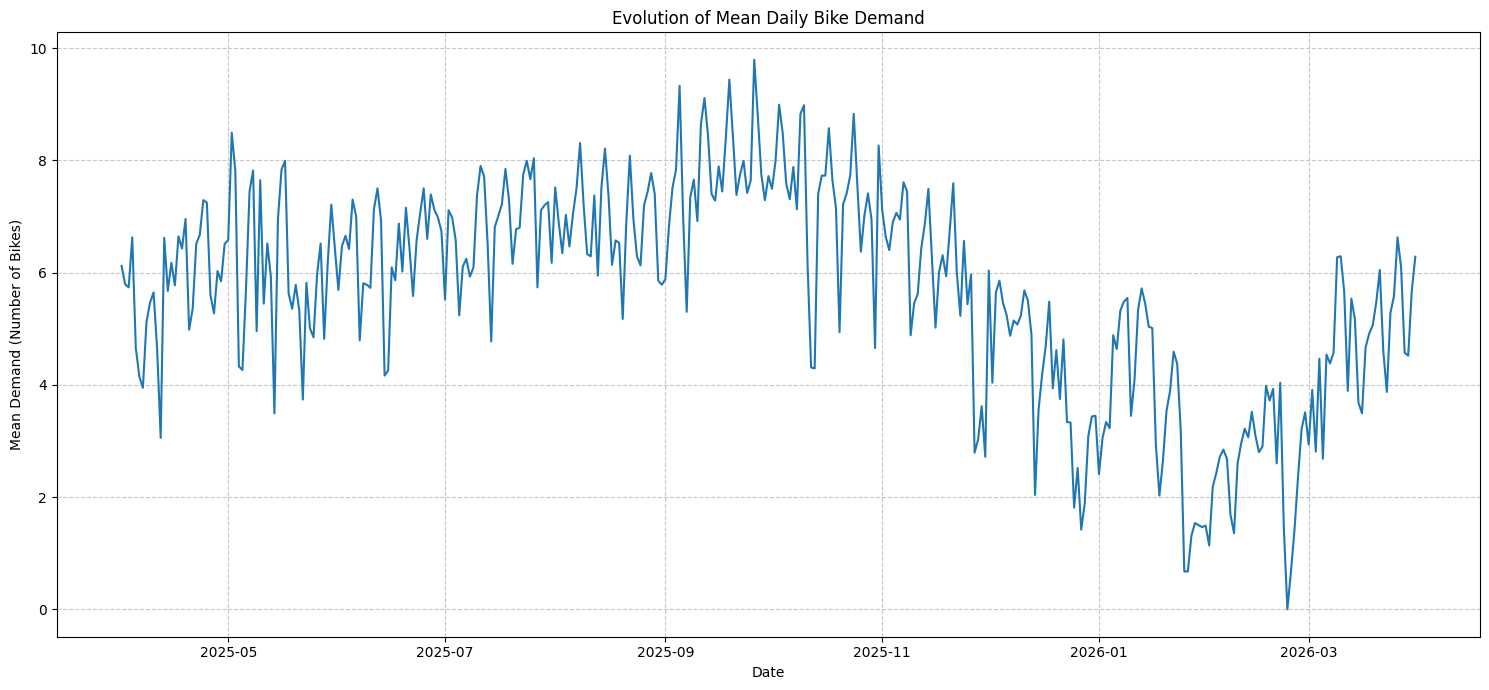

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean demand per day
daily_mean_demand = demand.groupby('date')['demand'].mean().reset_index()


# Create a line plot to visualize the evolution of daily mean demand
plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='demand', data=daily_mean_demand)
plt.title('Evolution of Mean Daily Bike Demand')
plt.xlabel('Date')
plt.ylabel('Mean Demand (Number of Bikes)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
merged_archetypes = archetype_000.merge(archetype_001, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_010, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_011, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_100, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_101, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_110, on='station_id', how='left')
merged_archetypes = merged_archetypes.merge(archetype_111, on='station_id', how='left')

# Merge with all_stations_geo to include coordinates
merged_archetypes = merged_archetypes.merge(all_stations_geo[['station_id', 'latitude', 'longitude']], on='station_id', how='left')

print("Merged Archetypes DataFrame created successfully with coordinates.")
display(merged_archetypes.head())
print(f"Shape of the Merged Archetypes DataFrame: {merged_archetypes.shape}")

Merged Archetypes DataFrame created successfully with coordinates.


,station_id,demand_000,demand_001,demand_010,demand_011,demand_100,demand_101,demand_110,demand_111,latitude,longitude
0,HB101,14.0,15.0,20.0,21.0,16.0,14.0,18.0,19.0,40.735938,-74.030305
1,HB102,0.0,0.0,11.0,12.0,0.0,0.0,14.0,8.0,40.736068,-74.029127
2,HB103,9.0,9.0,10.0,13.0,8.0,9.0,8.0,15.0,40.736982,-74.027781
3,HB105,8.0,8.0,12.0,14.0,7.0,8.0,12.0,12.0,40.737360,-74.030970
4,HB106,19.0,21.0,16.0,19.0,15.0,17.0,10.0,15.0,40.736722,-74.029007


Shape of the Merged Archetypes DataFrame: (110, 11)


In [20]:
output_file_name = 'all_archetypes_demand_with_coordinates_swap0.2723.csv'
merged_archetypes.to_csv(output_file_name, index=False)

print(f"'{output_file_name}' saved successfully.")

# Provide a link to download the file
from google.colab import files
files.download(output_file_name)

'all_archetypes_demand_with_coordinates_swap0.2723.csv' saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>